In [1]:
import os

import matplotlib.pyplot as plt
from dotenv import load_dotenv
from nixtla import NixtlaClient
from scipy.ndimage import gaussian_filter1d
import pandas as pd

complete_series_csv = '../data/complete_series.csv'
df = pd.read_csv(complete_series_csv, parse_dates=['timestamp'])

/tmp/ipykernel_66142/56028296.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['smoothed'][:length] = gaussian_filter1d(df['consumption_w'][:length], sigma=sigma)


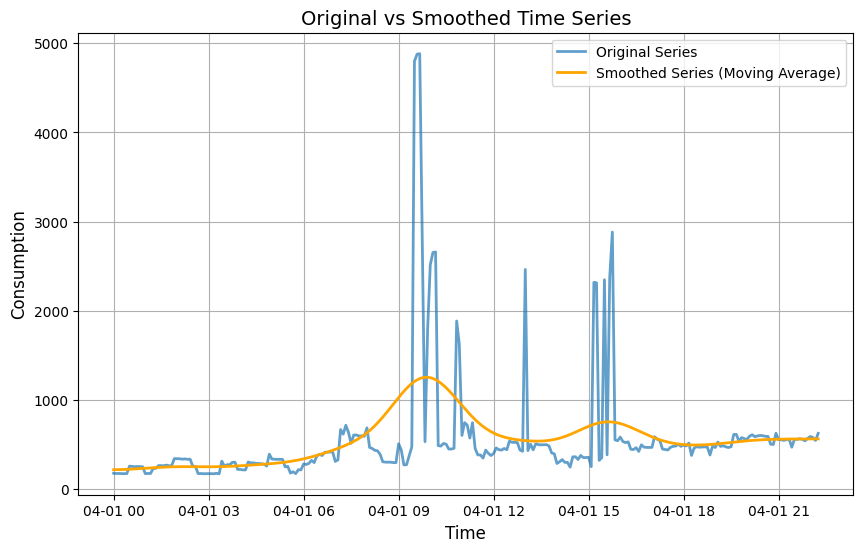

In [217]:
length = 268
sigma = 12  # Adjust to control smoothing intensity
df['smoothed'][:length] = gaussian_filter1d(df['consumption_w'][:length], sigma=sigma)

data = df[:length]
plt.figure(figsize=(10, 6))
plt.plot(data['timestamp'], data['consumption_w'], label='Original Series', alpha=0.7, linewidth=2)
plt.plot(data['timestamp'], data['smoothed'], label='Smoothed Series (Moving Average)', color='orange', linewidth=2)
plt.title('Original vs Smoothed Time Series', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Consumption', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [3]:
load_dotenv()
api_key = os.environ.get("NIXIA_API_KEY")

nixtla_client = NixtlaClient(
    api_key=api_key
)
nixtla_client.validate_api_key()
nixtla_client.plot(df, time_col='timestamp', target_col='smoothed')

nixak-GUdnOfO6VqhY28q8UdDiVHln6FxxeCNmhvnfKPdCg9zPE5M6affQ6fubdJFV3vLb90nElQdqnRtL4Gck


NameError: name 'df' is not defined

In [181]:
# Resample to 1-hour frequency, aggregating with mean (or another aggregation method)
df_resampled = df.set_index('timestamp').resample('1H').mean().reset_index()

/tmp/ipykernel_66142/2581735960.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df.set_index('timestamp').resample('1H').mean().reset_index()


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: h
/home/emanuele/IdeaProjects/EnergyManagementRL/.venv/lib/python3.10/site-packages/nixtla/nixtla_client.py:374: UserWarning: `df` contains the following exogenous features: ['Unnamed: 0', 'grid_voltage', 'consumption_w'], but they were not found in `X_df` nor declared in `hist_exog_list`. They will be ignored.
  warnings.warn(
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using future exogenous features: ['production_w']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Calling Historical Forecast Endpoint...


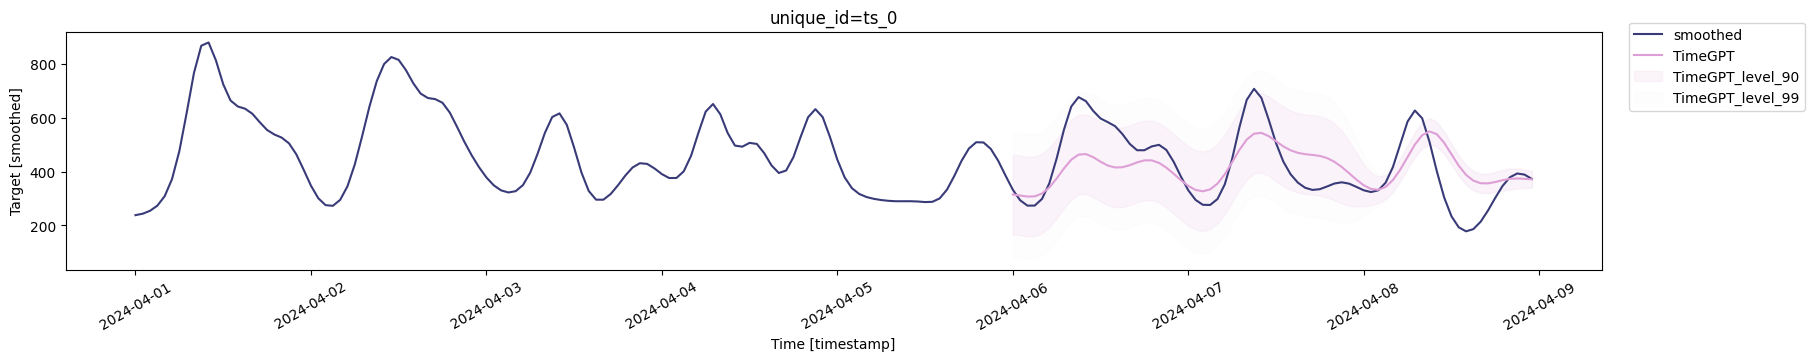

In [201]:
c_l = 24 * 7
h = 24
level = [90, 99]
# Use the resampled dataframe for forecasting
timegpt_fcst_df = nixtla_client.forecast(
    df=df_resampled[:c_l],
    h=h,
    time_col='timestamp',
    target_col='smoothed',
    X_df=df_resampled[c_l:c_l + h][['timestamp', 'production_w']],
    model='timegpt-1',
    # quantiles=quantiles, 
    add_history=True,
    finetune_steps=10,
    finetune_depth=5,
    level=level,
)

timegpt_fcst_df['TimeGPT'] = gaussian_filter1d(timegpt_fcst_df['TimeGPT'], sigma=2)
for l in level:
    for a in ['lo', 'hi']:
        timegpt_fcst_df[f'TimeGPT-{a}-{l}'] = gaussian_filter1d(timegpt_fcst_df[f'TimeGPT-{a}-{l}'], sigma=2)
# Plot the original data with forecasts
nixtla_client.plot(
    df_resampled[:c_l + h],
    timegpt_fcst_df,
    time_col='timestamp',
    target_col='smoothed',
    level=level,
)